In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

file_path = '/content/drive/MyDrive/Dataset (Code Alpha)/german.data.txt'

columns = [
    "checking_account_status", "duration_months", "credit_history", "purpose",
    "credit_amount", "savings_account", "present_employment_since",
    "installment_rate_pct", "personal_status_sex", "other_debtors_guarantors",
    "present_residence_since", "property", "age", "other_installment_plans",
    "housing", "existing_credits_count", "job", "num_dependents",
    "telephone", "foreign_worker", "target"
]

df = pd.read_csv(file_path, sep=' ', header=None, names=columns)

# Convert target: 1 = Good credit, 2 = Bad credit -> 0 = Good, 1 = Bad
df['target'] = df['target'].map({1: 0, 2: 1})

print(df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(1000, 21)


,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,present_employment_since,installment_rate_pct,personal_status_sex,other_debtors_guarantors,...,property,age,other_installment_plans,housing,existing_credits_count,job,num_dependents,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,1


In [ ]:
# Basic info
print(df.info())
print("\nMissing values:\n", df.isnull().sum().sum())

# Target distribution
print("\nTarget distribution:")
print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True))

# Numeric feature summary
numeric_cols = ['duration_months', 'credit_amount', 'installment_rate_pct',
                 'present_residence_since', 'age', 'existing_credits_count', 'num_dependents']
df[numeric_cols].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   checking_account_status   1000 non-null   object
 1   duration_months           1000 non-null   int64 
 2   credit_history            1000 non-null   object
 3   purpose                   1000 non-null   object
 4   credit_amount             1000 non-null   int64 
 5   savings_account           1000 non-null   object
 6   present_employment_since  1000 non-null   object
 7   installment_rate_pct      1000 non-null   int64 
 8   personal_status_sex       1000 non-null   object
 9   other_debtors_guarantors  1000 non-null   object
 10  present_residence_since   1000 non-null   int64 
 11  property                  1000 non-null   object
 12  age                       1000 non-null   int64 
 13  other_installment_plans   1000 non-null   object
 14  housing                  

,duration_months,credit_amount,installment_rate_pct,present_residence_since,age,existing_credits_count,num_dependents
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

categorical_cols = df_encoded.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", categorical_cols)

# Label encode each categorical column (simple + effective for tree-based models)
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    encoders[col] = le

X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train target distribution:\n", y_train.value_counts(normalize=True))
print("Test target distribution:\n", y_test.value_counts(normalize=True))

Categorical columns to encode: ['checking_account_status', 'credit_history', 'purpose', 'savings_account', 'present_employment_since', 'personal_status_sex', 'other_debtors_guarantors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']
Train shape: (800, 20) Test shape: (200, 20)
Train target distribution:
 target
0    0.7
1    0.3
Name: proportion, dtype: float64
Test target distribution:
 target
0    0.7
1    0.3
Name: proportion, dtype: float64


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Scale features for Logistic Regression (tree models don't need this)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Decision Tree
dt = DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)
dt.fit(X_train, y_train)

# Random Forest
rf = RandomForestClassifier(class_weight='balanced', n_estimators=200, max_depth=8, random_state=42)
rf.fit(X_train, y_train)

print("All 3 models trained.")

All 3 models trained.



Logistic Regression
              precision    recall  f1-score   support

 Good Credit       0.86      0.70      0.77       140
  Bad Credit       0.51      0.73      0.60        60

    accuracy                           0.71       200
   macro avg       0.69      0.72      0.69       200
weighted avg       0.76      0.71      0.72       200

ROC-AUC Score: 0.7908

Decision Tree
              precision    recall  f1-score   support

 Good Credit       0.82      0.69      0.75       140
  Bad Credit       0.48      0.65      0.55        60

    accuracy                           0.68       200
   macro avg       0.65      0.67      0.65       200
weighted avg       0.72      0.68      0.69       200

ROC-AUC Score: 0.6610

Random Forest
              precision    recall  f1-score   support

 Good Credit       0.85      0.86      0.86       140
  Bad Credit       0.67      0.63      0.65        60

    accuracy                           0.80       200
   macro avg       0.76      0.75

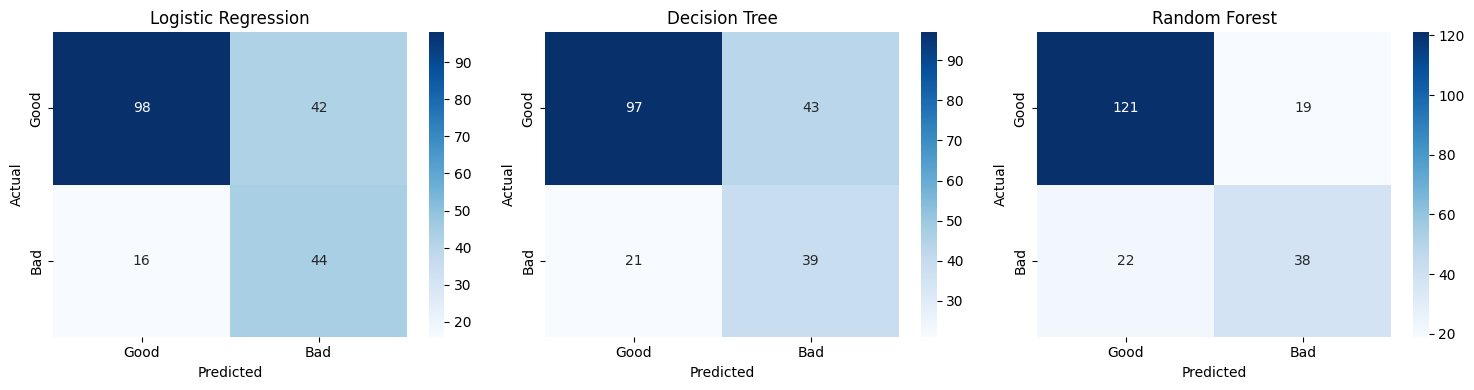

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

models = {
    "Logistic Regression": (log_reg, X_test_scaled),
    "Decision Tree": (dt, X_test),
    "Random Forest": (rf, X_test)
}

results = {}

for name, (model, X_te) in models.items():
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    roc_auc = roc_auc_score(y_test, y_proba)
    results[name] = roc_auc

    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=['Good Credit', 'Bad Credit']))
    print(f"ROC-AUC Score: {roc_auc:.4f}")

# Summary comparison
print("\n\nROC-AUC Comparison:")
for name, score in sorted(results.items(), key=lambda x: -x[1]):
    print(f"{name}: {score:.4f}")

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, (model, X_te)) in zip(axes, models.items()):
    y_pred = model.predict(X_te)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Good', 'Bad'], yticklabels=['Good', 'Bad'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

                     feature  importance
0    checking_account_status    0.156013
4              credit_amount    0.111076
1            duration_months    0.103203
12                       age    0.083313
5            savings_account    0.069681
2             credit_history    0.064066
3                    purpose    0.054114
6   present_employment_since    0.052328
11                  property    0.047308
13   other_installment_plans    0.038949
7       installment_rate_pct    0.037819
8        personal_status_sex    0.029294
10   present_residence_since    0.028635
16                       job    0.028199
14                   housing    0.022833
15    existing_credits_count    0.018571
9   other_debtors_guarantors    0.018341
18                 telephone    0.015481
17            num_dependents    0.013636
19            foreign_worker    0.007140


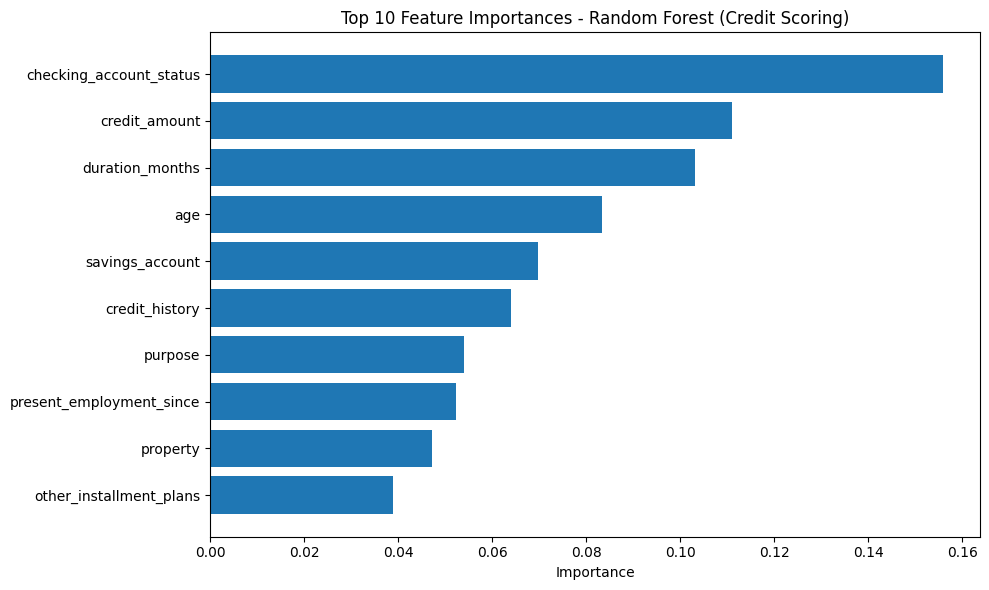

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'][:10][::-1], feature_importance['importance'][:10][::-1])
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances - Random Forest (Credit Scoring)')
plt.tight_layout()
plt.show()